In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sarimr/dogs-vs-cats-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogs-vs-cats-dataset' dataset.
Path to dataset files: /kaggle/input/dogs-vs-cats-dataset


In [2]:
!cp -r "/root/.cache/kagglehub/datasets/sarimr/dogs-vs-cats-dataset/versions/1/Dogs Vs Cats" /content/dogs_vs_cats

In [57]:
!tree -L 3 /content #ignore sample_data

/content
├── dogs_vs_cats
│   ├── test
│   │   ├── cats
│   │   └── dogs
│   └── train
│       ├── cats
│       └── dogs
├── friendliest-dog-breeds-lab-1578596713.jpg
├── images.jpg
└── sample_data
    ├── anscombe.json
    ├── california_housing_test.csv
    ├── california_housing_train.csv
    ├── mnist_test.csv
    ├── mnist_train_small.csv
    └── README.md

8 directories, 8 files


In [3]:
import tensorflow as tf
from tensorflow import keras

In [9]:
import os
import shutil

BASE_DIR = "/content/dogs_vs_cats"

TRAIN_SRC = f"{BASE_DIR}/train/train"
TEST_SRC  = f"{BASE_DIR}/test"

TRAIN_CAT = f"{BASE_DIR}/train/cats"
TRAIN_DOG = f"{BASE_DIR}/train/dogs"
TEST_CAT  = f"{BASE_DIR}/test/cats"
TEST_DOG  = f"{BASE_DIR}/test/dogs"

# create required folders
for path in [TRAIN_CAT, TRAIN_DOG, TEST_CAT, TEST_DOG]:
    os.makedirs(path, exist_ok=True)

# move training images (FILES ONLY)
for file in os.listdir(TRAIN_SRC):
    src = os.path.join(TRAIN_SRC, file)
    if not os.path.isfile(src):
        continue
    if file.lower().startswith("cat"):
        shutil.move(src, os.path.join(TRAIN_CAT, file))
    elif file.lower().startswith("dog"):
        shutil.move(src, os.path.join(TRAIN_DOG, file))

# move test images (FILES ONLY)
for file in os.listdir(TEST_SRC):
    src = os.path.join(TEST_SRC, file)
    if not os.path.isfile(src):
        continue
    if file.lower().startswith("cat"):
        shutil.move(src, os.path.join(TEST_CAT, file))
    elif file.lower().startswith("dog"):
        shutil.move(src, os.path.join(TEST_DOG, file))

print("✅ Dataset restructured successfully (files only)")

✅ Dataset restructured successfully (files only)


In [11]:
!rm -rf /content/dogs_vs_cats/train/train

In [25]:
from tensorflow.keras.utils import image_dataset_from_directory

In [13]:
from tensorflow.keras import layers

In [17]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 256, 256, 3)
(32,)


In [20]:
inputs = keras.Input(shape=(180,180,3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    loss = "binary_crossentropy",
    optimizer = "rmsprop",
    metrics = ["accuracy"]
)

In [23]:
from pathlib import Path

new_base_dir = Path("/content/dogs_vs_cats")

In [31]:
import tensorflow as tf

full_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/dogs_vs_cats/train",
    image_size=(180, 180),
    batch_size=32,
    shuffle=True,
    seed=42
)

Found 25000 files belonging to 2 classes.


In [32]:
dataset_size = len(full_ds)

train_size = int(0.7 * dataset_size)
val_size   = int(0.15 * dataset_size)

train_ds = full_ds.take(train_size)
remaining = full_ds.skip(train_size)

val_ds  = remaining.take(val_size)
test_ds = remaining.skip(val_size)

In [35]:
model.fit(train_ds,validation_data=val_ds,epochs=10)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.7988 - loss: 0.4306 - val_accuracy: 0.7596 - val_loss: 0.4879
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.8523 - loss: 0.3426 - val_accuracy: 0.8702 - val_loss: 0.3035
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - accuracy: 0.8862 - loss: 0.2757 - val_accuracy: 0.8721 - val_loss: 0.3039
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.9114 - loss: 0.2146 - val_accuracy: 0.8710 - val_loss: 0.3257
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.9325 - loss: 0.1703 - val_accuracy: 0.8782 - val_loss: 0.3463
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.9516 - loss: 0.1273 - val_accuracy: 0.8825 - val_loss: 0.3856
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 81s 75ms/step - accuracy: 0.9577 - loss: 0.1060 - val_accuracy: 0.8862 - val_loss: 0.4370
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.9688 - loss: 0.0874 - 

In [36]:
model.evaluate(test_ds)

118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8742 - loss: 0.5536


[0.5012070536613464, 0.8861940503120422]

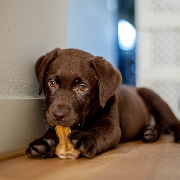

In [45]:
img_path = "/content/friendliest-dog-breeds-lab-1578596713.avif"
img = keras.utils.load_img(img_path, target_size=(180, 180))
img

In [46]:
img_array = keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis = 0)

In [52]:
prediction = model.predict(img_array)
print(prediction[0][0]*100 ,"%")
if prediction > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
99.99966 %
Dog
